# **BERT From Scratch on IMDb**

## Introduction

In this notebook, we implement the BERT architecture from first principles and train it on a real-world natural language processing task. The goal is to understand the internal structure and training dynamics of an encoder-only transformer model, rather than to rely on pretrained libraries or high-level abstractions. Every component of the model, including embeddings, multi-head self-attention, feed-forward networks, residual connections, and layer normalization, is implemented explicitly using PyTorch.

To ensure that the model operates on realistic language inputs, the IMDb movie review dataset is used for binary sentiment classification. Instead of a simple word-level tokenizer, we employ a byte pair encoding tokenizer via the tiktoken library, which provides subword tokenization and robust handling of previously unseen words. Special tokens required by BERT, such as classification, separator, and padding tokens, are added manually to align the tokenizer with the BERT input format.

The BERT model implemented here is intentionally smaller than the original BERT-Base architecture so that it can be trained from scratch on a single GPU within a reasonable time frame. While the resulting model does not match the performance of large pretrained models, it faithfully demonstrates how bidirectional self-attention and encoder-only transformers can be trained for sequence classification tasks in practice.


This notebook requires a small set of libraries to implement and train BERT from scratch. PyTorch is used for defining the model architecture and training loop. The datasets library is used only to load the IMDb dataset as raw text and labels. The tiktoken library provides a modern byte pair encoding tokenizer. tqdm is used for progress visualization during training, and scikit-learn is used for evaluation metrics. No pretrained models or transformer libraries are used.


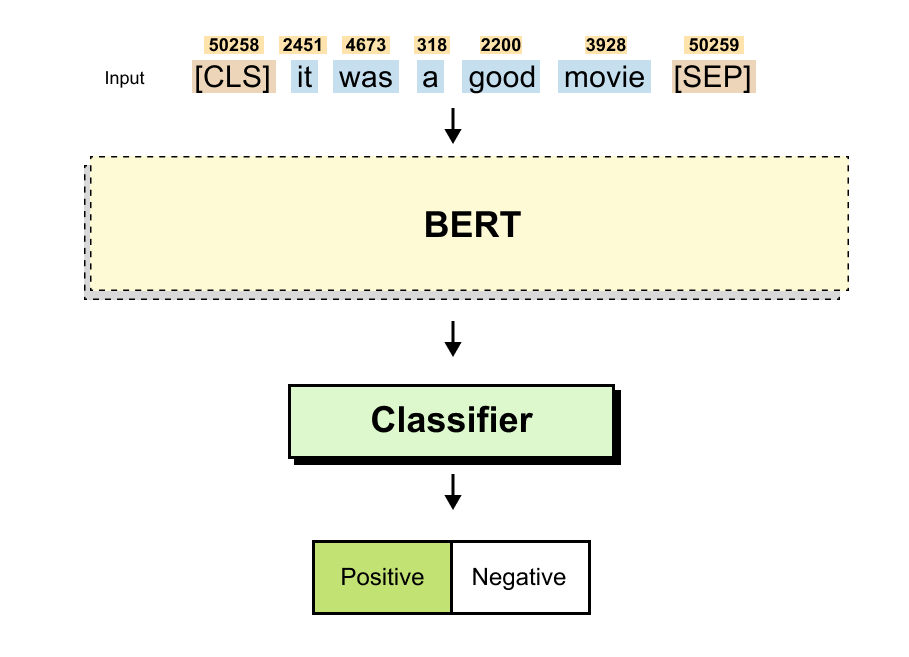

## **Listing 1.1  Installing the Required Dependencies**

This listing installs the minimal set of libraries required to implement and train BERT from scratch. PyTorch is used for defining the neural network architecture and training loop, the datasets library is used to load the IMDb dataset, tiktoken provides byte pair encoding tokenization, tqdm enables progress visualization, and scikit-learn is used for evaluation. No pretrained transformer libraries are installed.


In [ ]:
!pip install torch datasets tiktoken tqdm scikit-learn


## **Listing 1.2 Importing All Required Python Modules**

In [ ]:
import math
import os
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from tqdm import tqdm
import tiktoken

from sklearn.metrics import classification_report, confusion_matrix


## **Listing 1.3  Selecting the Compute Device**

This listing determines whether a CUDA-enabled GPU is available and selects the appropriate device for computation. If a GPU is available, the model and data will be moved to the GPU to accelerate training; otherwise, the CPU is used.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

## **Listing 1.4  Loading the IMDb Dataset**

This listing loads the IMDb movie review dataset, which contains 25,000 training samples and 25,000 test samples labeled for binary sentiment classification. Only the raw review text and sentiment labels are extracted, as tokenization and preprocessing are performed later.


In [ ]:
dataset = load_dataset("imdb")

train_texts = dataset["train"]["text"]
train_labels = dataset["train"]["label"]

test_texts = dataset["test"]["text"]
test_labels = dataset["test"]["label"]

len(train_texts), len(test_texts)


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

(25000, 25000)

In [ ]:
torch.tensor(train_labels).unique()

tensor([0, 1])

## **Listing 1.5 Initializing a Byte Pair Encoding Tokenizer**

This listing initializes a byte pair encoding tokenizer using the tiktoken library. The tokenizer operates at the byte level and produces subword tokens, which improves robustness to unseen words and reduces vocabulary sparsity compared to word-level tokenization.


In [ ]:
tokenizer = tiktoken.get_encoding("gpt2")
base_vocab_size = tokenizer.n_vocab
base_vocab_size


50257

## **Listing 1.6 Extending the Tokenizer with BERT Special Tokens**

This listing extends the tokenizer vocabulary by manually adding special tokens required by BERT. These include a classification token, a separator token, and a padding token. Each token is assigned a unique integer ID beyond the original tokenizer vocabulary.


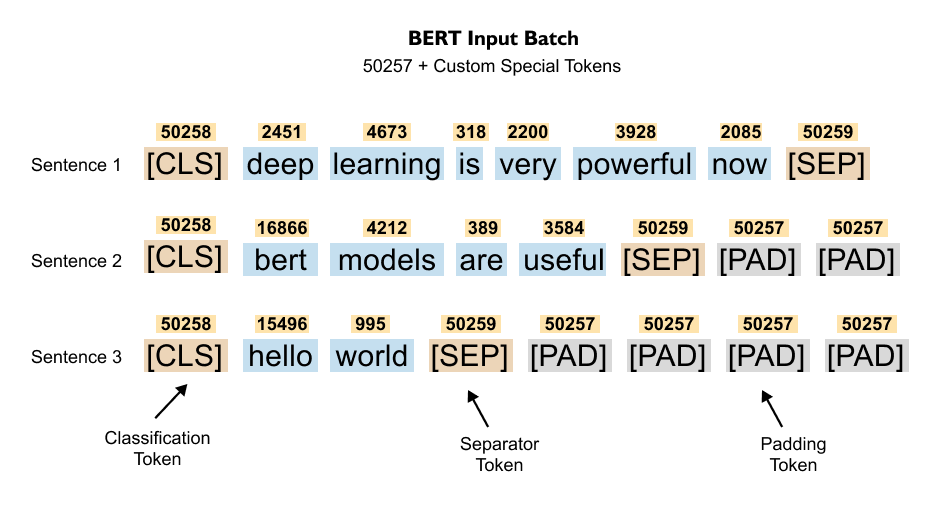

In [ ]:
PAD_ID = base_vocab_size
CLS_ID = base_vocab_size + 1
SEP_ID = base_vocab_size + 2

VOCAB_SIZE = base_vocab_size + 3
VOCAB_SIZE


50260

## **Listing 1.7 Encoding Text into Fixed-Length BERT Input Sequences**

This listing defines a function that converts raw text into a fixed-length sequence of token IDs. The text is tokenized using byte pair encoding, truncated to a maximum length, augmented with classification and separator tokens, and padded to ensure consistent input dimensions.


Note on Sequence Length: We limit the sequence length to 256 tokens to maintain training efficiency, as the self-attention mechanism's computational cost grows quadratically ($O(N^2)$) with length. While this speeds up processing, it uses "head-only" truncation which risks discarding important sentiment cues often found at the end of reviews; a "head+tail" strategy (keeping the first and last chunks) is often a more effective alternative for longer documents.

However, this is just a demonstration. If you want to increase accuracy, you can keep the entire text, but be aware that this will significantly increase training hours and computational costs.

In [ ]:
MAX_LEN = 256

def encode(text):
    token_ids = tokenizer.encode(text)
    token_ids = token_ids[:MAX_LEN - 2]

    token_ids = [CLS_ID] + token_ids + [SEP_ID]

    if len(token_ids) < MAX_LEN:
        token_ids += [PAD_ID] * (MAX_LEN - len(token_ids))

    return token_ids


## **Listing 1.8 Creating Attention Masks for Padding Tokens**

This listing defines a function that generates attention masks indicating which token positions correspond to valid input tokens and which correspond to padding. These masks are later used to prevent the attention mechanism from attending to padded positions.


In [ ]:
def create_attention_mask(input_ids):
    return (input_ids != PAD_ID).long()


## **Listing 1.9 Defining the IMDb Dataset Class**

This listing defines a custom PyTorch Dataset class for IMDb. Each sample is tokenized, padded, and paired with an attention mask and a sentiment label. The dataset returns these components in a format suitable for batching during training and evaluation.


In [ ]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = torch.tensor(encode(self.texts[idx]))
        mask = create_attention_mask(ids)
        label = torch.tensor(self.labels[idx])

        return ids, mask, label


## **Listing 1.10 Creating DataLoaders for Training and Evaluation**

This listing wraps the IMDb dataset using PyTorch DataLoader objects. The training DataLoader shuffles samples to improve generalization, while the evaluation DataLoader preserves sample order for consistent evaluation.


In [ ]:
train_ds = IMDBDataset(train_texts, train_labels)
test_ds = IMDBDataset(test_texts, test_labels)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=16)


## **Listing 1.11 Implementing the BERT Embedding Layer**

This listing implements the BERT embedding layer, which combines token embeddings, positional embeddings, and segment embeddings. These embeddings are summed and normalized to form the initial input representation for the transformer encoder.


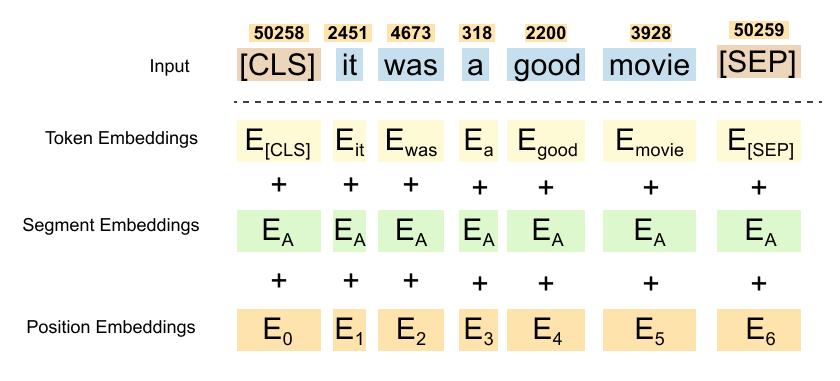

In [ ]:
class BERTEmbedding(nn.Module):
    def __init__(self, vocab_size, embed_dim, max_len, dropout=0.1):
        super().__init__()
        self.token = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.position = nn.Embedding(max_len, embed_dim)
        self.segment = nn.Embedding(2, embed_dim)
        self.norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T = x.size()
        pos = torch.arange(T).unsqueeze(0).to(x.device)
        seg = torch.zeros_like(x)

        embeddings = (
            self.token(x) +
            self.position(pos) +
            self.segment(seg)
        )

        embeddings = self.norm(embeddings)
        embeddings = self.dropout(embeddings)
        return embeddings


## **Listing 1.12 Implementing Multi-Head Self-Attention**

This listing implements bidirectional multi-head self-attention. Query, key, and value projections are computed from the input, split into multiple heads, and used to calculate scaled dot-product attention. Padding masks are applied to prevent attending to invalid positions.


In [ ]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, dim, heads, dropout=0.1):
        super().__init__()
        assert dim % heads == 0

        self.heads = heads
        self.d = dim // heads

        self.qkv = nn.Linear(dim, dim * 3)
        self.out = nn.Linear(dim, dim)

        self.attn_dropout = nn.Dropout(dropout)
        self.out_dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        B, T, C = x.shape

        q, k, v = self.qkv(x).chunk(3, dim=-1)

        q = q.view(B, T, self.heads, self.d).transpose(1, 2)
        k = k.view(B, T, self.heads, self.d).transpose(1, 2)
        v = v.view(B, T, self.heads, self.d).transpose(1, 2)

        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.d)

        mask = mask.unsqueeze(1).unsqueeze(2)
        scores = scores.masked_fill(mask == 0, -1e9)

        attn = F.softmax(scores, dim=-1)
        attn = self.attn_dropout(attn)

        out = attn @ v
        out = out.transpose(1, 2).reshape(B, T, C)

        out = self.out(out)
        out = self.out_dropout(out)
        return out


## **Listing 1.13 Implementing the Feed-Forward Network**

This listing defines the position-wise feed-forward network used inside each transformer encoder layer. The network consists of two linear transformations with a GELU activation, applied independently to each token position.


In [ ]:
class FeedForward(nn.Module):
    def __init__(self, dim, hidden, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)


## **Listing 1.14 Defining a Transformer Encoder Block**

This listing combines multi-head self-attention and the feed-forward network into a single transformer encoder block. Residual connections and layer normalization are applied around each sublayer to ensure stable training.


In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, dim, heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadSelfAttention(dim, heads, dropout)
        self.ff = FeedForward(dim, ff_dim, dropout)
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)

    def forward(self, x, mask):
        x = x + self.attn(self.norm1(x), mask)
        x = x + self.ff(self.norm2(x))
        return x


## **Listing 1.15 Constructing the BERT Encoder Stack**

This listing constructs the BERT encoder by stacking multiple transformer encoder blocks. Each layer refines token representations by incorporating bidirectional contextual information from the entire sequence.


In [ ]:
class BERTEncoder(nn.Module):
    def __init__(self, vocab_size, dim, max_len, layers, heads, ff_dim):
        super().__init__()
        self.embed = BERTEmbedding(vocab_size, dim, max_len)
        self.layers = nn.ModuleList([
            TransformerBlock(dim, heads, ff_dim)
            for _ in range(layers)
        ])

    def forward(self, x, mask):
        x = self.embed(x)
        for layer in self.layers:
            x = layer(x, mask)
        return x


## **Listing 1.16 Adding a Sequence Classification Head**

This listing defines the sequence classification head. The contextual representation of the classification token is extracted from the encoder output and passed through a linear layer to produce sentiment logits.


In [ ]:
class BERTForClassification(nn.Module):
    def __init__(self, vocab_size, dim, max_len, layers, heads, ff_dim):
        super().__init__()
        self.bert = BERTEncoder(
            vocab_size, dim, max_len, layers, heads, ff_dim
        )
        self.classifier = nn.Sequential(nn.Dropout(0.1),nn.Linear(dim, 2))

    def forward(self, x, mask):
        out = self.bert(x, mask)
        cls = out[:, 0]
        return self.classifier(cls)


## **Listing 1.17 Initializing the Model**

This listing initializes a smaller, trainable BERT model that mirrors the original architecture while remaining computationally feasible to train from scratch on a single GPU.


In [ ]:
model = BERTForClassification(
    vocab_size=VOCAB_SIZE,
    dim=256,
    max_len=MAX_LEN,
    layers=4,
    heads=6,
    ff_dim=1024
).to(device)

model


BERTForClassification(
  (bert): BERTEncoder(
    (embed): BERTEmbedding(
      (token): Embedding(50260, 256, padding_idx=50257)
      (position): Embedding(256, 256)
      (segment): Embedding(2, 256)
      (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (layers): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attn): MultiHeadSelfAttention(
          (qkv): Linear(in_features=256, out_features=768, bias=True)
          (out): Linear(in_features=256, out_features=256, bias=True)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (out_dropout): Dropout(p=0.1, inplace=False)
        )
        (ff): FeedForward(
          (net): Sequential(
            (0): Linear(in_features=256, out_features=1024, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.1, inplace=False)
            (3): Linear(in_features=1024, out_features=256, bias=True)
            (4): Dropout(p=

## **Listing 1.18 Defining the Loss Function and Optimizer**

This listing sets up the training objective and optimization algorithm. Cross-entropy loss is used for binary classification, and the AdamW optimizer is employed due to its effectiveness with transformer architectures.


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)


## **Listing 1.19 Training the Model**

This listing implements the training loop. For each epoch, the model processes all training batches, computes the loss, performs backpropagation, and updates model parameters. Training loss is reported at the end of each epoch.


In [ ]:
EPOCHS = 100

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for ids, mask, labels in tqdm(train_loader):
        ids, mask, labels = ids.to(device), mask.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(ids, mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Train Loss: {total_loss:.2f}")


100%|██████████| 1563/1563 [00:52<00:00, 29.91it/s]


Epoch 1 | Train Loss: 1026.36


100%|██████████| 1563/1563 [00:50<00:00, 30.72it/s]


Epoch 2 | Train Loss: 792.58


100%|██████████| 1563/1563 [00:50<00:00, 30.69it/s]


...

Epoch 98 | Train Loss: 3.65


100%|██████████| 1563/1563 [00:51<00:00, 30.40it/s]


Epoch 99 | Train Loss: 4.33


100%|██████████| 1563/1563 [00:51<00:00, 30.42it/s]

Epoch 100 | Train Loss: 5.88


## **Listing 1.20 Evaluating the Model**

This listing evaluates the trained model on the test dataset. Gradients are disabled to reduce memory usage, and classification accuracy is computed by comparing predictions with ground truth labels.


In [ ]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for ids, mask, labels in loader:
            ids, mask, labels = ids.to(device), mask.to(device), labels.to(device)
            preds = model(ids, mask).argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total


In [ ]:
accuracy = evaluate(model, test_loader)
print("Test Accuracy:", accuracy)


Test Accuracy: 0.8074


In [ ]:
all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for ids, mask, labels in test_loader:
        preds = model(ids.to(device), mask.to(device)).argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=["Negative", "Positive"]))


              precision    recall  f1-score   support

    Negative       0.81      0.80      0.81     12500
    Positive       0.81      0.81      0.81     12500

    accuracy                           0.81     25000
   macro avg       0.81      0.81      0.81     25000
weighted avg       0.81      0.81      0.81     25000



## **Listing 1.21 Saving the Trained Model**

This listing saves the trained model parameters along with tokenizer metadata required for reproducibility and future inference.


In [ ]:
SAVE_DIR = "bert_from_scratch_imdb"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(model.state_dict(), f"{SAVE_DIR}/model.pt")

torch.save({
    "pad_id": PAD_ID,
    "cls_id": CLS_ID,
    "sep_id": SEP_ID,
    "max_len": MAX_LEN
}, f"{SAVE_DIR}/tokenizer_info.pt")

print("Model saved successfully!")


Model saved successfully!


## **Listing 1.22 Running Inference on New Text**

This final listing demonstrates end-to-end inference using the trained model on a custom input sentence. The text is tokenized, an attention mask is created, and the predicted sentiment label is produced.


In [ ]:
model.load_state_dict(torch.load(f"{SAVE_DIR}/model.pt", map_location=device))
model.eval()
print("Model loaded successfully!")


Model loaded successfully!


In [ ]:
text = "Bromwell High is a brilliantly conceived, executed and acted, but sadly overlooked sitcom. The writing is razor sharp, the characters are well drawn and the jokes are genuinely funny. The animation is also excellent, with a style that suits the material perfectly. It's a shame that it didn't get a proper chance in the UK, as it deserves to be up there with the likes of The Simpsons and South Park. Highly recommended for anyone who likes clever, witty humour."

ids = torch.tensor([encode(text)]).to(device)
mask = (ids != PAD_ID).long()

with torch.no_grad():
    pred = model(ids, mask).argmax(dim=1).item()

print("Prediction:", "Positive" if pred == 1 else "Negative")


Prediction: Positive


In [ ]:
text = "In fact I must confess, so bad was it I fast forwarded through most of the garbage... As for the title characters, they barely even have a footnote in the film."

ids = torch.tensor([encode(text)]).to(device)
mask = (ids != PAD_ID).long()

with torch.no_grad():
    pred = model(ids, mask).argmax(dim=1).item()

print("Prediction:", "Positive" if pred == 1 else "Negative")


Prediction: Negative


In [ ]:
text = "This movie was a complete waste of time. The dialogue was cringe-worthy and the story made no sense at all."

ids = torch.tensor([encode(text)]).to(device)
mask = (ids != PAD_ID).long()

with torch.no_grad():
    pred = model(ids, mask).argmax(dim=1).item()

print("Prediction:", "Positive" if pred == 1 else "Negative")


Prediction: Negative


In [ ]:
text = "Beautifully shot and brilliantly acted, this is one of the most moving films I have seen in years."

ids = torch.tensor([encode(text)]).to(device)
mask = (ids != PAD_ID).long()

with torch.no_grad():
    pred = model(ids, mask).argmax(dim=1).item()

print("Prediction:", "Positive" if pred == 1 else "Negative")


Prediction: Positive
